In [16]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.ensemble import VotingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# ============================================
# STEP 1: LOAD DATA (FIX HEADERS)
# ============================================

df_raw = pd.read_excel(
    r"C:\Users\Kunal Kaushal\Downloads\BLOODREPORT.xlsx",
    header=[0, 1]
)

# Clean headers
clean_cols = []
for col in df_raw.columns:
    biomarker = str(col[0]).strip().lower()
    organ = str(col[1]).strip().lower()

    if "unnamed" in biomarker:
        biomarker = organ
    if "unnamed" in organ:
        organ = biomarker

    clean_cols.append(f"{organ}_{biomarker}")

df_raw.columns = clean_cols
df = df_raw.copy()

# Clean categorical
df = df.replace({
    "Yes": 1, "No": 0,
    "yes": 1, "no": 0,
    "Active": 1, "Moderate": 0.5, "Sedentary": 0
})

df = df.apply(pd.to_numeric, errors='ignore')


# ============================================
# STEP 2: ORGAN GROUPS
# ============================================

organ_groups = {
    "cardiovascular": ["cholesterol", "ldl", "hdl", "triglyceride", "vldl"],
    "hepatic": ["alt", "ast", "bilirubin", "albumin", "protein"],
    "renal": ["creatinine", "urea", "bun", "uric"],
    "hematology": ["hemoglobin", "rbc", "wbc", "platelet"],
    "metabolic": ["glucose", "hba1c", "insulin"]
}


# ============================================
# STEP 3: CATEGORY SCORES
# ============================================

def compute_category_scores(df, groups):
    category_scores = pd.DataFrame()

    for organ, keywords in groups.items():
        matched_cols = []

        for col in df.columns:
            for key in keywords:
                if key in col:
                    matched_cols.append(col)

        matched_cols = list(set(matched_cols))

        if len(matched_cols) == 0:
            continue

        sub_df = df[matched_cols]
        score = (sub_df - sub_df.mean()) / (sub_df.std() + 1e-5)
        score = score.fillna(0)

        category_scores[organ] = score.abs().mean(axis=1)

    return category_scores


# ============================================
# STEP 4: CONTEXT
# ============================================

def apply_context(scores, df):
    modified = scores.copy()

    age_col = [c for c in df.columns if "age" in c]
    if age_col:
        modified = modified.multiply(1 + df[age_col[0]] / 100, axis=0)

    smoker_col = [c for c in df.columns if "smoker" in c]
    if smoker_col:
        modified["cardiovascular"] *= (1 + df[smoker_col[0]] * 0.3)

    return modified


# ============================================
# STEP 5: LABELS
# ============================================
def create_labels(scores):
    labels = pd.DataFrame()

    for col in scores.columns:
        # Add noise to break perfect pattern
        noisy = scores[col] + np.random.normal(0, 0.2, len(scores))
        
        threshold = noisy.quantile(0.6)  # slightly stricter than median
        
        labels[col] = (noisy > threshold).astype(int)

    return labels

# ============================================
# STEP 6: MODEL COMPARISON
# ============================================

def compare_models(X, y):
    results = []

    models_dict = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Random Forest": RandomForestClassifier(n_estimators=100),
        "Gradient Boosting": GradientBoostingClassifier()
    }

    for organ in y.columns:
        y_target = y[organ]

        if len(y_target.unique()) < 2:
            continue

        print(f"\n===== {organ.upper()} =====")

        X_train, X_test, y_train, y_test = train_test_split(
            X, y_target, test_size=0.2, random_state=42
        )

        for name, model in models_dict.items():

            pipeline = Pipeline([
                ("imputer", SimpleImputer(strategy="mean")),
                ("scaler", StandardScaler()),
                ("model", model)
            ])

            pipeline.fit(X_train, y_train)
            preds = pipeline.predict(X_test)

            acc = accuracy_score(y_test, preds)
            f1 = f1_score(y_test, preds, zero_division=0)

            results.append({
                "Organ": organ,
                "Model": name,
                "Accuracy": acc,
                "F1 Score": f1
            })

            print(f"{name}: Acc={acc:.2f}, F1={f1:.2f}")

    return pd.DataFrame(results)


# ============================================
# STEP 7: TRAIN FINAL MODELS
# ============================================

def train_models(X, y):
    models = {}

    for organ in y.columns:
        y_target = y[organ]

        if len(y_target.unique()) < 2:
            continue

        model = VotingClassifier(
            estimators=[
                ("lr", LogisticRegression(max_iter=1000)),
                ("rf", RandomForestClassifier(n_estimators=100)),
                ("gb", GradientBoostingClassifier())
            ],
            voting='soft'
        )

        pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler", StandardScaler()),
            ("model", model)
        ])

        pipeline.fit(X, y_target)
        models[organ] = pipeline

    return models


# ============================================
# STEP 8: PREDICTION
# ============================================

def predict_risk(models, X):
    results = {}

    for organ, model in models.items():
        results[organ] = model.predict_proba(X)[:, 1]

    return pd.DataFrame(results)


# ============================================
# STEP 9: PIPELINE EXECUTION
# ============================================

category_scores = compute_category_scores(df, organ_groups)
adjusted = apply_context(category_scores, df)

# Use only partial features for training (breaks leakage)
X = adjusted.sample(frac=0.8, axis=1, random_state=42)
feature_cols = X.columns
labels = create_labels(adjusted)
# MODEL COMPARISON
comparison_df = compare_models(X, labels)
print("\n===== MODEL COMPARISON =====")
print(comparison_df)

best_models = comparison_df.loc[
    comparison_df.groupby("Organ")["F1 Score"].idxmax()
]

print("\n===== BEST MODEL PER ORGAN =====")
print(best_models)

# TRAIN FINAL MODELS
models = train_models(X, labels)
# GLOBAL SCORES (IMPORTANT FIX)
global_scores = adjusted.copy()

# ============================================
# STEP 10: PATIENT-LEVEL FUNCTION
# ============================================

def get_patient_risk(patient_id, df, models, global_scores, feature_cols):

    # Find patient column
    patient_col = [c for c in df.columns if "patient_id" in c][0]

    # Filter patient
    patient_rows = df[df[patient_col].astype(str).str.lower() == patient_id.lower()]

    if patient_rows.empty:
        print("❌ Patient not found")
        return

    idx = patient_rows.index[0]

    # Use same features as training
    patient_scores = global_scores.loc[[idx], feature_cols]

    # Predict
    patient_risk = predict_risk(models, patient_scores) * 100

    print("\n==============================")
    print(f"PATIENT ID: {patient_id}")
    print("==============================")

    print("\nPatient Details:")

    clean_cols = [c for c in df.columns if any(k in c for k in 
                  ["patient_id", "age", "gender", "city", "state", "activity", "sleep", "smoker"])]

    for col in clean_cols:
        print(f"{col.split('_')[0]}: {df.loc[idx, col]}")

    print("\nOrgan Risk (%):")

    for organ, value in patient_risk.iloc[0].items():

        if value > 70:
            level = "HIGH RISK"
        elif value > 40:
            level = "MODERATE"
        else:
            level = "LOW"

        print(f"{organ.upper():15} : {value:.2f}% → {level}")
# ============================================
# STEP 11: INTERACTIVE LOOP
# ============================================

while True:
    user_input = input("\nEnter Patient ID (or 'exit'): ")

    if user_input.lower() == "exit":
        break

    get_patient_risk(user_input, df, models, global_scores, feature_cols)


C:\Users\Kunal Kaushal\AppData\Local\Temp\ipykernel_3300\3980188394.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({
C:\Users\Kunal Kaushal\AppData\Local\Temp\ipykernel_3300\3980188394.py:46: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')



===== CARDIOVASCULAR =====
Logistic Regression: Acc=0.89, F1=0.86
Random Forest: Acc=0.87, F1=0.84
Gradient Boosting: Acc=0.89, F1=0.86

===== HEPATIC =====
Logistic Regression: Acc=0.82, F1=0.77
Random Forest: Acc=0.81, F1=0.75
Gradient Boosting: Acc=0.81, F1=0.77

===== RENAL =====
Logistic Regression: Acc=0.86, F1=0.84
Random Forest: Acc=0.88, F1=0.86
Gradient Boosting: Acc=0.86, F1=0.84

===== HEMATOLOGY =====
Logistic Regression: Acc=0.61, F1=0.44
Random Forest: Acc=0.67, F1=0.57
Gradient Boosting: Acc=0.66, F1=0.54

===== METABOLIC =====
Logistic Regression: Acc=0.89, F1=0.85
Random Forest: Acc=0.89, F1=0.85
Gradient Boosting: Acc=0.89, F1=0.86

===== MODEL COMPARISON =====
             Organ                Model  Accuracy  F1 Score
0   cardiovascular  Logistic Regression    0.8850  0.859756
1   cardiovascular        Random Forest    0.8725  0.841121
2   cardiovascular    Gradient Boosting    0.8850  0.855346
3          hepatic  Logistic Regression    0.8250  0.772727
4         


Enter Patient ID (or 'exit'):  PO2


❌ Patient not found



Enter Patient ID (or 'exit'):  P01



PATIENT ID: P01

Patient Details:
patient: P01
age: 36
gender: Female
city: Hyderabad
state: Telangana
activity: 1.0
sleep: 10
smoker: 1
prostate: 41.03
prostate: 78.33

Organ Risk (%):
CARDIOVASCULAR  : 48.65% → MODERATE
HEPATIC         : 1.01% → LOW
RENAL           : 79.72% → HIGH RISK
HEMATOLOGY      : 23.04% → LOW
METABOLIC       : 0.36% → LOW



Enter Patient ID (or 'exit'):  P99



PATIENT ID: P99

Patient Details:
patient: P99
age: 69
gender: Female
city: Thane
state: Maharashtra
activity: 0.0
sleep: 6
smoker: 0
prostate: 4.29
prostate: 51.74

Organ Risk (%):
CARDIOVASCULAR  : 0.59% → LOW
HEPATIC         : 93.60% → HIGH RISK
RENAL           : 97.96% → HIGH RISK
HEMATOLOGY      : 38.94% → LOW
METABOLIC       : 4.57% → LOW



Enter Patient ID (or 'exit'):  exit


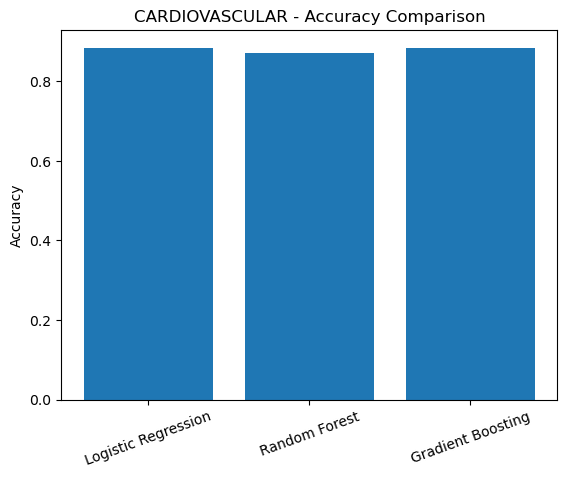

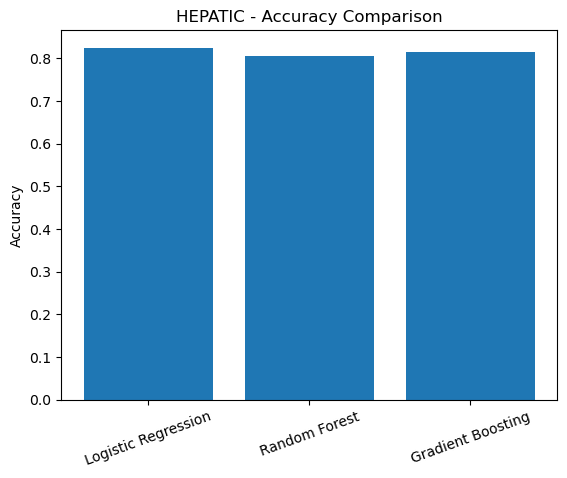

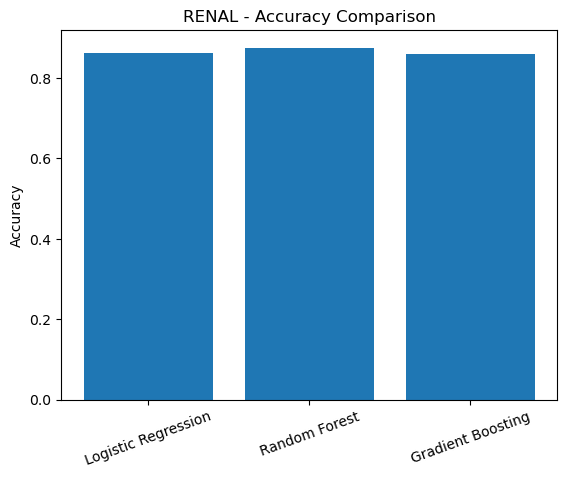

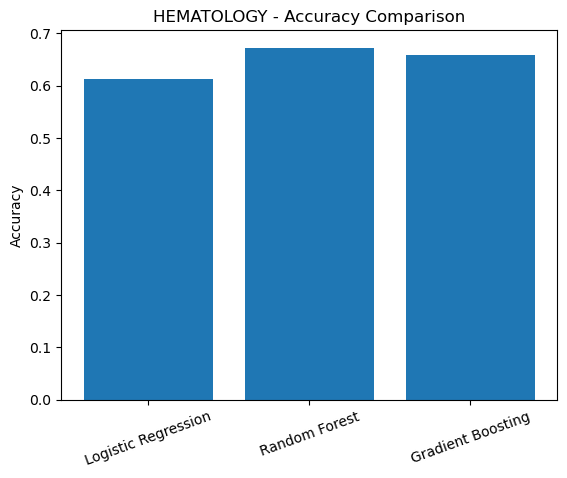

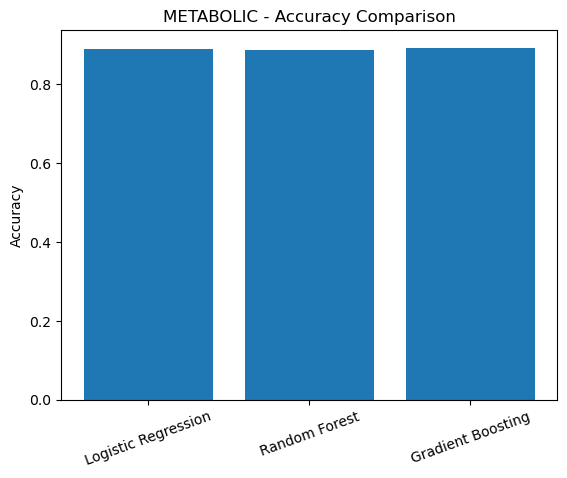

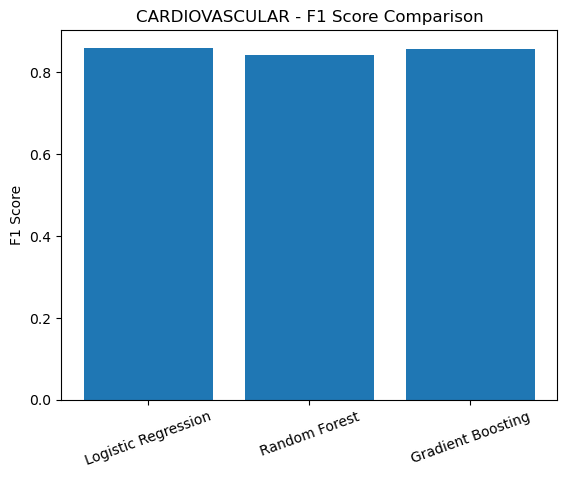

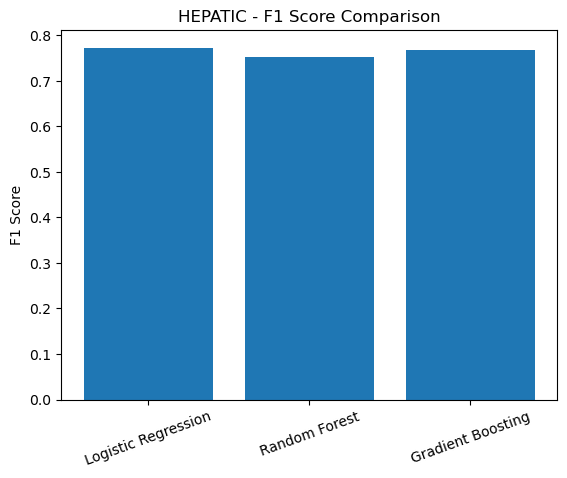

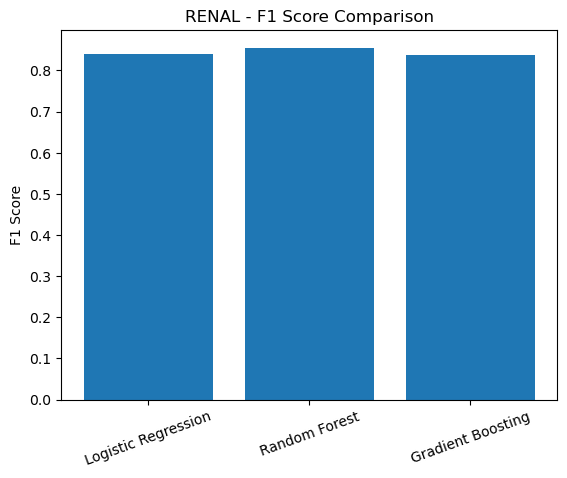

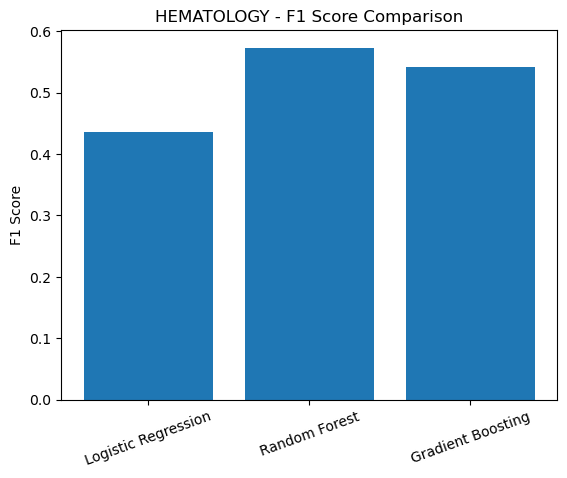

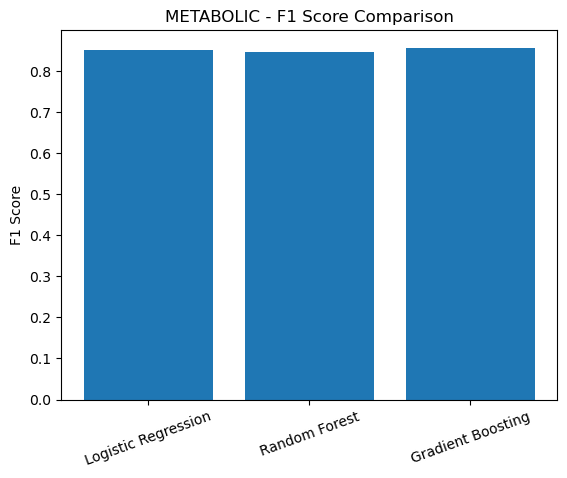

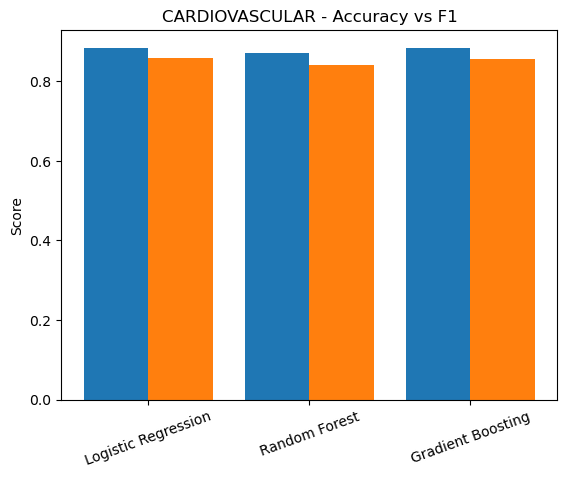

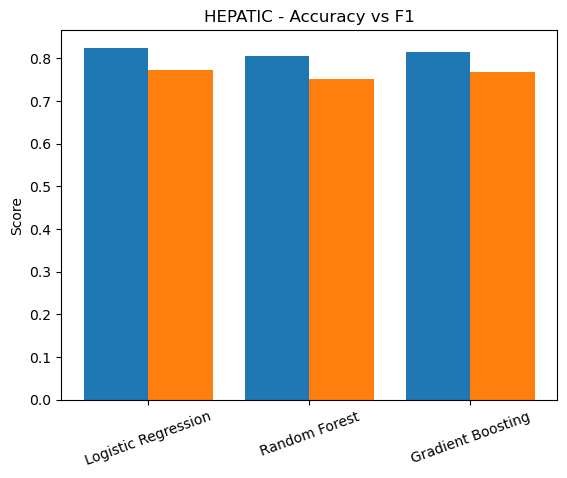

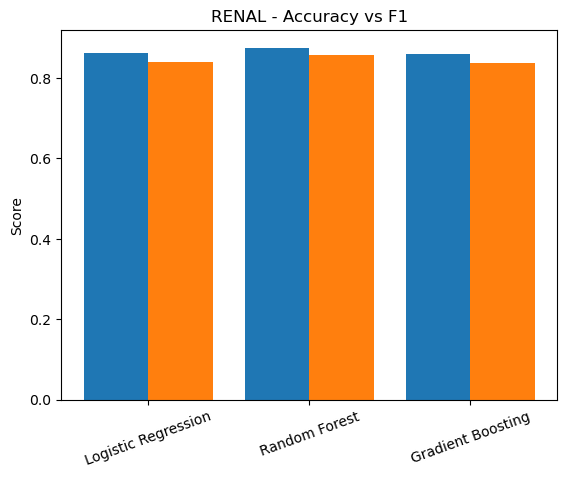

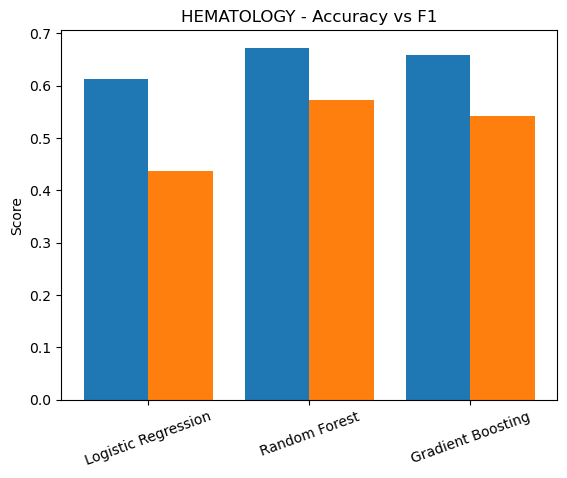

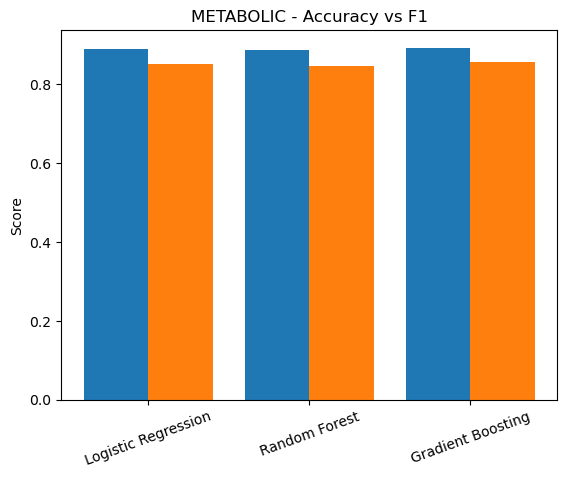

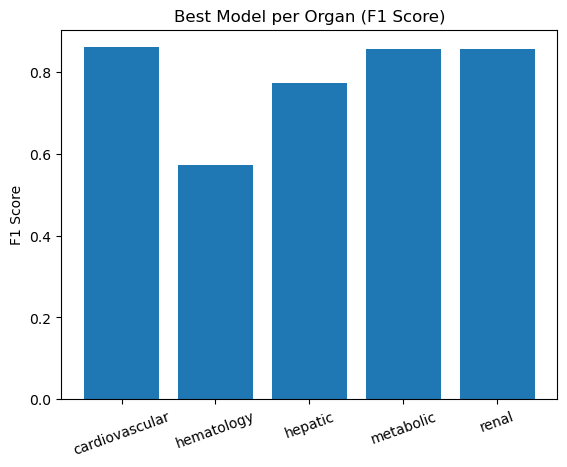

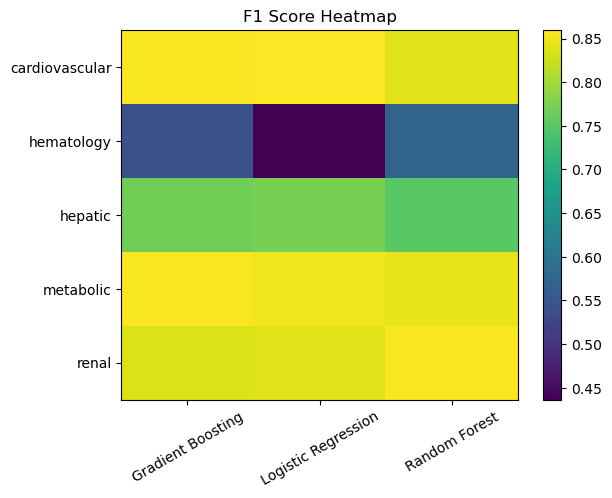

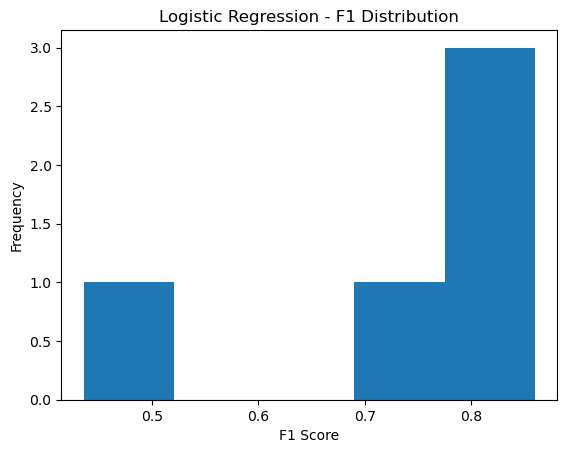

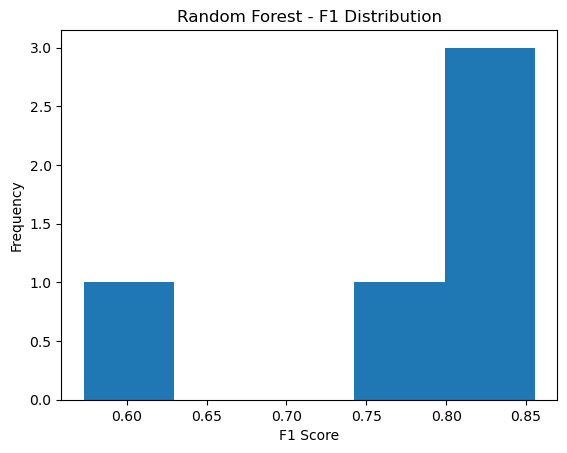

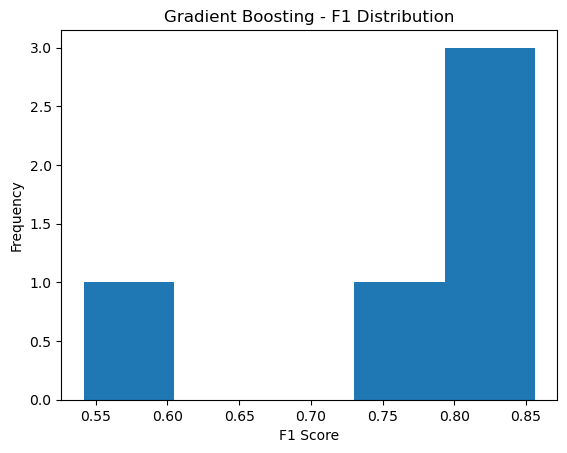

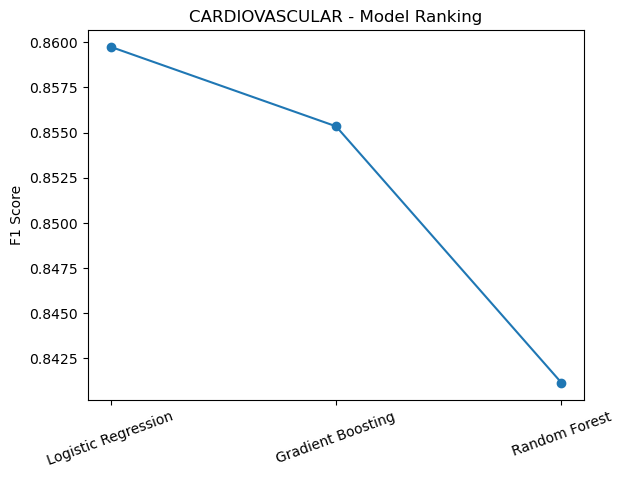

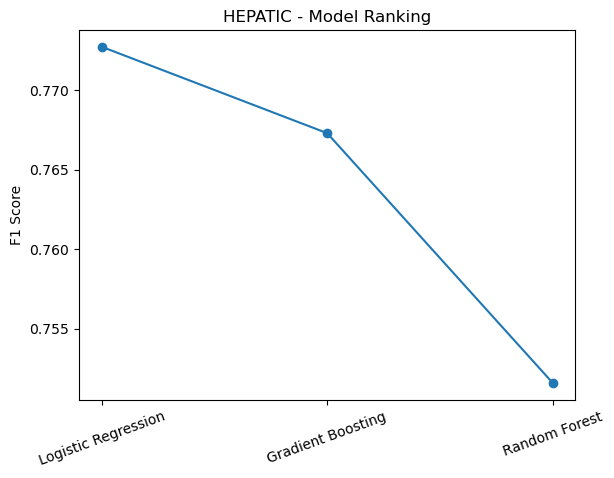

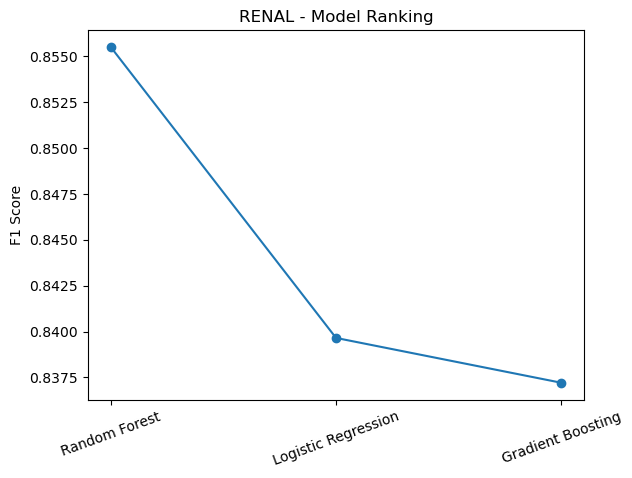

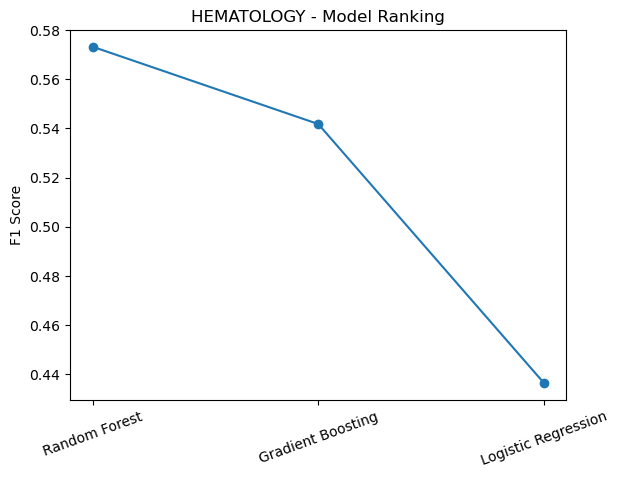

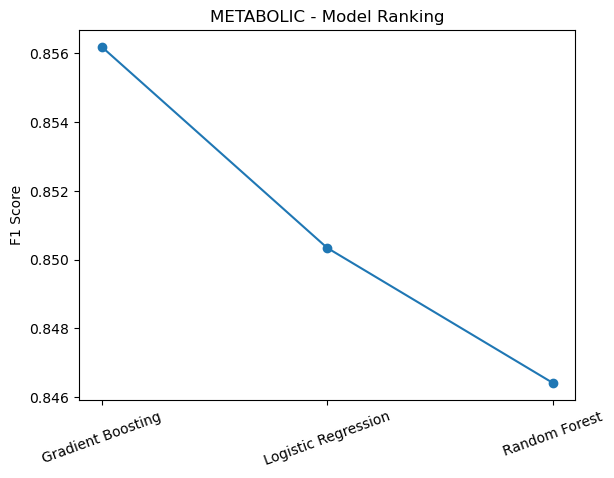

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# 1. Accuracy Comparison per Organ
# ============================================

def plot_accuracy(comparison_df):
    for organ in comparison_df["Organ"].unique():
        subset = comparison_df[comparison_df["Organ"] == organ]
        
        plt.figure()
        plt.bar(subset["Model"], subset["Accuracy"])
        plt.title(f"{organ.upper()} - Accuracy Comparison")
        plt.xticks(rotation=20)
        plt.ylabel("Accuracy")
        plt.show()


# ============================================
# 2. F1 Score Comparison per Organ
# ============================================

def plot_f1(comparison_df):
    for organ in comparison_df["Organ"].unique():
        subset = comparison_df[comparison_df["Organ"] == organ]
        
        plt.figure()
        plt.bar(subset["Model"], subset["F1 Score"])
        plt.title(f"{organ.upper()} - F1 Score Comparison")
        plt.xticks(rotation=20)
        plt.ylabel("F1 Score")
        plt.show()


# ============================================
# 3. Accuracy vs F1 (Grouped Bar)
# ============================================

def plot_accuracy_vs_f1(comparison_df):
    for organ in comparison_df["Organ"].unique():
        subset = comparison_df[comparison_df["Organ"] == organ]
        
        x = np.arange(len(subset))
        
        plt.figure()
        plt.bar(x - 0.2, subset["Accuracy"], width=0.4)
        plt.bar(x + 0.2, subset["F1 Score"], width=0.4)
        
        plt.xticks(x, subset["Model"], rotation=20)
        plt.title(f"{organ.upper()} - Accuracy vs F1")
        plt.ylabel("Score")
        plt.show()


# ============================================
# 4. Best Model per Organ
# ============================================

def plot_best_models(best_models):
    plt.figure()
    
    x = np.arange(len(best_models))
    plt.bar(x, best_models["F1 Score"])
    
    plt.xticks(x, best_models["Organ"], rotation=20)
    plt.title("Best Model per Organ (F1 Score)")
    plt.ylabel("F1 Score")
    
    plt.show()


# ============================================
# 5. Heatmap Style (Matrix View)
# ============================================

def plot_heatmap(comparison_df):
    pivot = comparison_df.pivot(index="Organ", columns="Model", values="F1 Score")
    
    plt.figure()
    plt.imshow(pivot, aspect='auto')
    
    plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=30)
    plt.yticks(range(len(pivot.index)), pivot.index)
    
    plt.colorbar()
    plt.title("F1 Score Heatmap")
    
    plt.show()


# ============================================
# 6. Model Performance Distribution
# ============================================

def plot_model_distribution(comparison_df):
    for model in comparison_df["Model"].unique():
        subset = comparison_df[comparison_df["Model"] == model]
        
        plt.figure()
        plt.hist(subset["F1 Score"], bins=5)
        plt.title(f"{model} - F1 Distribution")
        plt.xlabel("F1 Score")
        plt.ylabel("Frequency")
        plt.show()


# ============================================
# 7. Organ-wise Ranking Plot
# ============================================

def plot_ranking(comparison_df):
    for organ in comparison_df["Organ"].unique():
        subset = comparison_df[comparison_df["Organ"] == organ]
        subset = subset.sort_values("F1 Score", ascending=False)
        
        plt.figure()
        plt.plot(subset["Model"], subset["F1 Score"], marker='o')
        plt.title(f"{organ.upper()} - Model Ranking")
        plt.ylabel("F1 Score")
        plt.xticks(rotation=20)
        plt.show()


# ============================================
# CALL ALL PLOTS
# ============================================

plot_accuracy(comparison_df)
plot_f1(comparison_df)
plot_accuracy_vs_f1(comparison_df)
plot_best_models(best_models)
plot_heatmap(comparison_df)
plot_model_distribution(comparison_df)
plot_ranking(comparison_df)
